## Import Library

In [1]:
import os
import platform
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from itertools import combinations

print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")

NB6_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook05a"
NB7_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook06"

MODEL_NAMES = ["Decision Tree", "LightGBM", "XGBoost", "TCN", "GRU", "CNN-LSTM"]
ALPHA = 0.05

nb6 = pd.read_csv(f"{NB6_DIR}/nb6_results.csv")
nb7 = pd.read_csv(f"{NB7_DIR}/nb7_results.csv")

print(f"\nnb6_results: {len(nb6)} baris, seed unik ({nb6['seed'].nunique()}): {sorted(nb6['seed'].unique())}")
print(f"nb7_results: {len(nb7)} baris, seed unik ({nb7['seed'].nunique()}): {sorted(nb7['seed'].unique())}")


def build_family(df, paired_unit_col, family_name):
    wide = df.pivot_table(index=paired_unit_col, columns="model", values="f1", aggfunc="mean")
    wide = wide.reindex(columns=MODEL_NAMES)
    n_incomplete = wide.isna().any(axis=1).sum()
    if n_incomplete > 0:
        print(f"  [{family_name}] {n_incomplete} paired_unit tidak lengkap (ada model kosong).")
        wide = wide.dropna()
    return wide


FAMILIES = {}

for scen in ["in_distribution", "extra", "variants", "mix"]:
    sub = nb6[nb6.scenario == scen].copy()
    FAMILIES[scen] = build_family(sub, "seed", scen)

nb7_primary = nb7[nb7.scenario == "held_out_hw"].copy()
nb7_primary["paired_unit"] = nb7_primary["exclusion_name"] + "|" + nb7_primary["seed"].astype(str)
for kind in ["individual", "freq_subgroup", "cpu_subgroup", "capacity_subgroup"]:
    sub = nb7_primary[nb7_primary.exclusion_kind == kind].copy()
    FAMILIES[kind] = build_family(sub, "paired_unit", kind)

print(f"\n Ukuran tiap keluarga skenario ({len(FAMILIES)} total) ")
for name, wide in FAMILIES.items():
    print(f"  {name:20s} n_paired_unit={len(wide):4d}")


python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3

nb6_results: 240 baris, seed unik (10): [np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]
nb7_results: 5280 baris, seed unik (10): [np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]

 Ukuran tiap keluarga skenario (8 total) 
  in_distribution      n_paired_unit=  10
  extra                n_paired_unit=  10
  variants             n_paired_unit=  10
  mix                  n_paired_unit=  10
  individual           n_paired_unit= 120
  freq_subgroup        n_paired_unit=  60
  cpu_subgroup         n_paired_unit=  20
  capacity_subgroup    n_paired_unit=  20


## Uji Wilcoxon Signed-Rank per Keluarga Skenario + Koreksi Holm-Bonferroni

In [2]:
def holm_bonferroni(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    m = len(pvalues)
    order = np.argsort(pvalues)
    adjusted = np.empty(m)
    running_max = 0.0
    for rank, idx in enumerate(order):
        adj = (m - rank) * pvalues[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


MODEL_PAIRS = list(combinations(MODEL_NAMES, 2))
rows = []

for family, wide in FAMILIES.items():
    raw_p = []
    pair_stats = []
    for a, b in MODEL_PAIRS:
        xa, xb = wide[a].to_numpy(), wide[b].to_numpy()
        diff = xa - xb
        if np.allclose(diff, 0):
            stat, p = np.nan, 1.0
        else:
            try:
                stat, p = wilcoxon(xa, xb)
            except ValueError:
                stat, p = np.nan, 1.0
        raw_p.append(p)
        pair_stats.append((a, b, np.median(diff), stat, p))

    p_holm = holm_bonferroni(raw_p)
    for (a, b, med_diff, stat, p), p_adj in zip(pair_stats, p_holm):
        if p_adj < ALPHA and med_diff > 0:
            winner = a
        elif p_adj < ALPHA and med_diff < 0:
            winner = b
        else:
            winner = None
        rows.append([family, a, b, len(wide), med_diff, stat, p, p_adj, winner])

nb8_pairwise = pd.DataFrame(rows, columns=[
    "family", "model_a", "model_b", "n_pairs", "median_diff_a_minus_b",
    "wilcoxon_stat", "p_raw", "p_holm", "winner",
])
nb8_pairwise.to_csv("/kaggle/working/nb8_pairwise_results.csv", index=False)

n_significant = nb8_pairwise["winner"].notna().sum()
print(f"Total uji: {len(nb8_pairwise)} ({len(FAMILIES)} keluarga x {len(MODEL_PAIRS)} pasangan model)")

for family in FAMILIES:
    print(f"\n {family} (n={len(FAMILIES[family])}) ")
    sub = nb8_pairwise[nb8_pairwise.family == family]
    show = sub[["model_a", "model_b", "median_diff_a_minus_b", "p_raw", "p_holm", "winner"]].copy()
    show["median_diff_a_minus_b"] = show["median_diff_a_minus_b"].round(4)
    show["p_raw"] = show["p_raw"].round(4)
    show["p_holm"] = show["p_holm"].round(4)
    show["winner"] = show["winner"].fillna("-")
    print(show.to_string(index=False))

Total uji: 120 (8 keluarga x 15 pasangan model)

 in_distribution (n=10) 
      model_a  model_b  median_diff_a_minus_b  p_raw  p_holm        winner
Decision Tree LightGBM                -0.0273 0.0020  0.0293      LightGBM
Decision Tree  XGBoost                -0.0247 0.0059  0.0469       XGBoost
Decision Tree      TCN                 0.0042 0.3223  0.9668             -
Decision Tree      GRU                 0.0505 0.0020  0.0293 Decision Tree
Decision Tree CNN-LSTM                -0.0104 0.3750  0.9668             -
     LightGBM  XGBoost                 0.0024 0.4922  0.9668             -
     LightGBM      TCN                 0.0388 0.0039  0.0391      LightGBM
     LightGBM      GRU                 0.0772 0.0020  0.0293      LightGBM
     LightGBM CNN-LSTM                 0.0294 0.0098  0.0586             -
      XGBoost      TCN                 0.0316 0.0059  0.0469       XGBoost
      XGBoost      GRU                 0.0720 0.0020  0.0293       XGBoost
      XGBoost CNN-LSTM    

## Rekap Kemenangan Signifikan per Model + Visualisasi

 Rekap jumlah kemenangan signifikan per model, per keluarga skenario 
               in_distribution  extra  variants  mix  individual  freq_subgroup  cpu_subgroup  capacity_subgroup  TOTAL
XGBoost                      4      2         1    1           4              4             4                  4     24
LightGBM                     3      2         1    1           4              4             4                  4     23
CNN-LSTM                     1      2         0    0           3              3             1                  0     10
Decision Tree                1      0         0    0           1              0             1                  3      6
TCN                          0      2         1    1           1              0             0                  0      5
GRU                          0      0         1    1           0              0             1                  0      3

 Median F1 per model, per keluarga skenario (konteks skala, bukan hasil uji) 
           

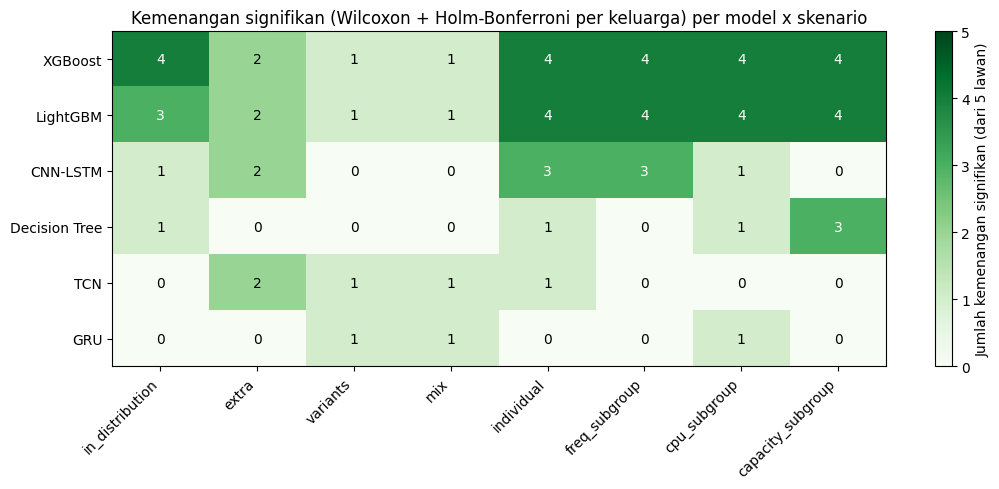

In [3]:
import matplotlib.pyplot as plt

win_counts = pd.DataFrame(0, index=MODEL_NAMES, columns=list(FAMILIES.keys()))
for _, r in nb8_pairwise.iterrows():
    if pd.notna(r["winner"]):
        win_counts.loc[r["winner"], r["family"]] += 1

win_counts["TOTAL"] = win_counts.sum(axis=1)
win_counts = win_counts.sort_values("TOTAL", ascending=False)

print(" Rekap jumlah kemenangan signifikan per model, per keluarga skenario ")
print(win_counts.to_string())

print("\n Median F1 per model, per keluarga skenario (konteks skala, bukan hasil uji) ")
median_f1 = pd.DataFrame({name: wide.median() for name, wide in FAMILIES.items()}).reindex(index=MODEL_NAMES)
print(median_f1.round(4).to_string())

plot_data = win_counts.drop(columns="TOTAL")
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(plot_data.values, cmap="Greens", vmin=0, vmax=5, aspect="auto")
ax.set_xticks(range(len(plot_data.columns)))
ax.set_xticklabels(plot_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(plot_data.index)))
ax.set_yticklabels(plot_data.index)
for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        ax.text(j, i, plot_data.values[i, j], ha="center", va="center",
                color="white" if plot_data.values[i, j] > 2.5 else "black")
fig.colorbar(im, label="Jumlah kemenangan signifikan (dari 5 lawan)")
ax.set_title("Kemenangan signifikan (Wilcoxon + Holm-Bonferroni per keluarga) per model x skenario")
plt.tight_layout()
plt.savefig("/kaggle/working/nb8_win_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
mix_data = nb6[nb6.scenario == "mix"].copy()
mix_wide = mix_data.pivot_table(index="seed", columns="model", values="f1").reindex(columns=MODEL_NAMES)

print(" F1 per seed, skenario 'mix', semua model ")
print(mix_wide.round(4).to_string())

print("\n Statistik ringkas per model, skenario 'mix' ")
summary = mix_wide.agg(["mean", "std", "min", "max"]).T
print(summary.round(4).to_string())

print("\n Fokus CNN-LSTM, diurutkan ")
cnn_vals = mix_wide["CNN-LSTM"].sort_values()
print(cnn_vals.to_string())
n_low = (cnn_vals < 0.5).sum()

print("\n Jumlah seed dengan F1 < 0.5, semua model (skenario 'mix') ")
for m in MODEL_NAMES:
    n = (mix_wide[m] < 0.5).sum()
    print(f"  {m:14s}: {n}/{len(mix_wide)} seed")

 F1 per seed, skenario 'mix', semua model 
model  Decision Tree  LightGBM  XGBoost     TCN     GRU  CNN-LSTM
seed                                                             
42            0.5507    0.7013   0.5401  0.7097  0.5294    0.4615
43            0.7342    0.6395   0.8304  0.7654  0.6486    0.4733
44            0.4375    0.6014   0.6395  0.8950  0.8439    0.5294
45            0.6395    0.6577   0.7179  0.7261  0.7179    0.3471
46            0.6667    0.6111   0.6301  0.7805  0.7421    0.5075
47            0.6395    0.6577   0.6755  0.8235  0.6577    0.4252
48            0.8889    0.8166   0.7097  0.8024  0.6301    0.3871
49            0.8889    0.5714   0.5612  0.8372  0.5401    0.4000
50            0.5714    0.7500   0.7261  0.6207  0.7879    0.6395
51            0.8827    0.5816   0.7421  0.7730  0.8636    0.4252

 Statistik ringkas per model, skenario 'mix' 
                 mean     std     min     max
model                                        
Decision Tree  0.6900  0.1